## Task Overview

In this lab you will use a **Long Short-Term Memory (LSTM)** network to forecast a
**time series**: monthly totals of international airline passengers from 1949 to
1960 ([Airline Passengers dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv)).

**After completing this task, you will know how to:**

- Load a time series and prepare it for a recurrent network
- Scale the data correctly (using training statistics only)
- Turn a sequence into **sliding windows** of (past values -> next value)
- Build and train an LSTM for one-step forecasting
- Evaluate the forecast and plot predictions against the real values

**How it's different from image classification:** with time series the **order
matters**. We split the data by time (not randomly), fit the scaler on the
training portion only, and predict a continuous number (regression) instead of a
class.

## Task

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise
indicated. Fill in every cell marked `## Answer here`.

### Static code

In [1]:
# @title Importing Necessary Packages

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

Matplotlib is building the font cache; this may take a moment.


In [2]:
# @title Device, seed helper, and data URL

# Use a GPU if one is available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    """Fix all random number generators for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# Public URL for the classic Airline Passengers dataset (144 monthly totals).
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

Using device: cpu


### Task 1
#### **Load and prepare the time series (Steps 1-3)**

In this task you will:

1) Load the Airline Passengers data and plot it.
2) Scale the values and split the series chronologically into train and test.
3) Build sliding-window sequences and wrap them in a `DataLoader`.

#### Step 1: Load and plot the data

Read the CSV from `data_url` with `pandas`. The file has two columns, `Month`
and `Passengers`. Extract the `Passengers` column as a float array called
`series` and plot it. You should see an upward trend with a repeating yearly
(seasonal) pattern.

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Number of months: 144


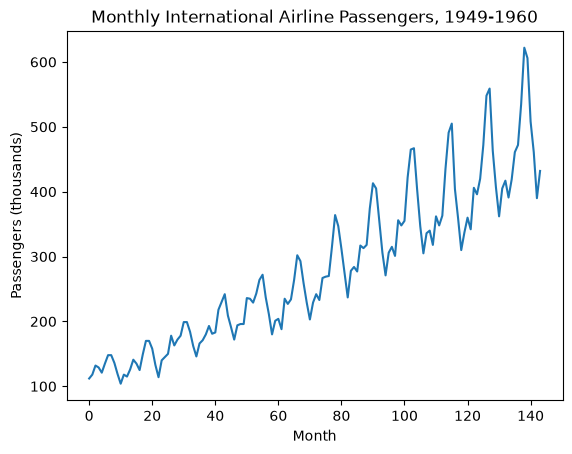

In [3]:
df = pd.read_csv(data_url)
series = df["Passengers"].values.astype("float32")

print(df.head())
print("Number of months:", len(series))

plt.plot(series)
plt.xlabel("Month")
plt.ylabel("Passengers (thousands)")
plt.title("Monthly International Airline Passengers, 1949-1960")
plt.show()


Check: `df.head()` and the month count should print:

         Month  Passengers
    0  1949-01         112
    1  1949-02         118
    2  1949-03         132
    3  1949-04         129
    4  1949-05         121
    Number of months: 144

and the plot of the raw series should look like this — an upward trend with a repeating yearly (seasonal) pattern:

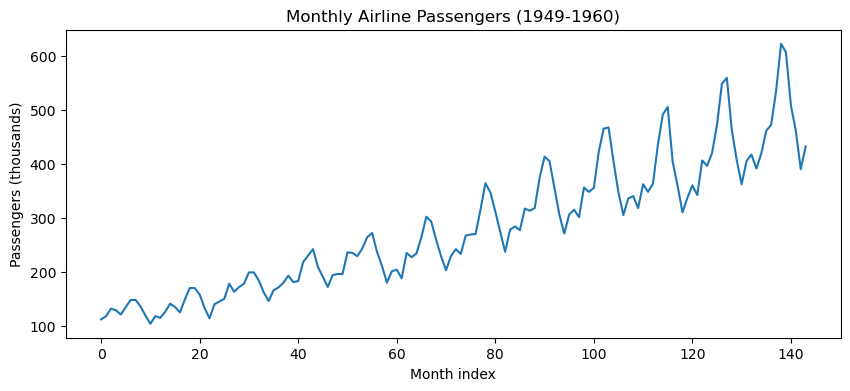

#### Step 2: Scale and split the series

Hold out the **last 12 months** as the test set (`test_size = 12`). Scale the
series to the range [0, 1] using the **minimum and maximum of the training
portion only** -- using the whole series would leak future information into
training. Keep `train_min` and `train_max`; you'll need them to convert
predictions back to real passenger counts later.

In [4]:
test_size = 12
split_idx = len(series) - test_size

train_min = series[:split_idx].min()
train_max = series[:split_idx].max()

scaled = (series - train_min) / (train_max - train_min)

train_series = scaled[:split_idx]
test_series = scaled[split_idx:]

print(f"Train months: {len(train_series)} | Test months: {len(test_series)}")


Train months: 132 | Test months: 12


Check: You should see:

    Train months: 132 | Test months: 12

#### Step 3: Build sliding windows and a DataLoader

An LSTM learns from short sub-sequences. Use a window of `seq_length = 12`
months: each input `X` is 12 consecutive months and the target `y` is the very
next month. Build these windows, reshape `X` to `(num_windows, seq_length, 1)`
(the LSTM expects a feature dimension), split them into train/test by their
target month, and wrap the training windows in a `DataLoader` (`batch_size = 16`).

In [5]:
seq_length = 12

def make_windows(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

X_all, y_all = make_windows(scaled, seq_length)

target_idx = np.arange(seq_length, len(scaled))
train_mask = target_idx < split_idx
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[~train_mask], y_all[~train_mask]

X_train = torch.from_numpy(X_train).unsqueeze(-1)
X_test = torch.from_numpy(X_test).unsqueeze(-1)
y_train = torch.from_numpy(y_train).unsqueeze(-1)
y_test = torch.from_numpy(y_test).unsqueeze(-1)

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=False)


Check: Print the shapes. You should see:

    X_train shape: torch.Size([120, 12, 1])
    y_train shape: torch.Size([120, 1])
    X_test shape:  torch.Size([12, 12, 1])
    y_test shape:  torch.Size([12, 1])

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape: torch.Size([120, 12, 1])
y_train shape: torch.Size([120, 1])
X_test shape:  torch.Size([12, 12, 1])
y_test shape:  torch.Size([12, 1])


### Task 2
#### **Build the LSTM forecasting model**

Define a model class `LSTMForecaster` that:

1) Runs the input sequence through an `nn.LSTM(input_size=1, hidden_size=50,
   batch_first=True)`.
2) Takes the output of the **last timestep** (it has seen the whole window).
3) Passes it through `nn.Linear(50, 1)` to predict the next value.

In [7]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=50):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last)


Check: Instantiate the model and run 5 windows through it. The output shape
should be `torch.Size([5, 1])` (one predicted value per input window).

In [8]:
set_seed(1)                       # reproducible weight initialization
model = LSTMForecaster().to(device)
print(model)

# Quick shape test: run 5 windows through the untrained model.
sample = X_train[:5].to(device)
print("Output shape:", model(sample).shape)   # expect torch.Size([5, 1])

LSTMForecaster(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Output shape: torch.Size([5, 1])


### Task 3
#### **Train the model**

Use **mean squared error** (`nn.MSELoss`) since we're predicting a continuous
value, plus the Adam optimizer. This dataset is tiny, so training many epochs is
fast. Print the loss every few epochs.

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
num_epochs = 150

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{num_epochs} | loss: {epoch_loss:.5f}")


Epoch  10/150 | loss: 0.01432
Epoch  20/150 | loss: 0.00709
Epoch  30/150 | loss: 0.00768


Epoch  40/150 | loss: 0.00534
Epoch  50/150 | loss: 0.00402
Epoch  60/150 | loss: 0.00296


Epoch  70/150 | loss: 0.00754
Epoch  80/150 | loss: 0.00389
Epoch  90/150 | loss: 0.00324


Epoch 100/150 | loss: 0.00479
Epoch 110/150 | loss: 0.00480
Epoch 120/150 | loss: 0.00325


Epoch 130/150 | loss: 0.00222
Epoch 140/150 | loss: 0.00159
Epoch 150/150 | loss: 0.00143


Check: The loss should fall over training (exact numbers vary a little from run to run), ending well below `0.01` — for example:

    Epoch  10/150 | loss: 0.01432
    Epoch  50/150 | loss: 0.00402
    Epoch 100/150 | loss: 0.00510
    Epoch 150/150 | loss: 0.00113

### Task 4
#### **Evaluate and visualize the forecast**

#### Step 1: Predict and measure error

Put the model in eval mode and predict on `X_test` (inside `torch.no_grad()`).
Convert the predictions and true values back to real passenger counts by
inverting the scaling (`value * (train_max - train_min) + train_min`), then
compute the test **RMSE** (root mean squared error).

In [10]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test.to(device))

test_pred = test_pred.cpu().numpy().flatten()

def inverse(x):
    return x * (train_max - train_min) + train_min

test_pred_real = inverse(test_pred)
y_test_real = inverse(y_test.numpy().flatten())

rmse = np.sqrt(np.mean((test_pred_real - y_test_real) ** 2))
print(f"Test RMSE: {rmse:.2f} thousand passengers")


Test RMSE: 27.61 thousand passengers


Check: The test error should be roughly:

    Test RMSE: 29.40 thousand passengers

(Your exact value will vary a little depending on training randomness — anything in the ~25-35 range is expected.)

#### Step 2: Plot the forecast

Plot the full actual series, then overlay the model's test predictions on the
final 12 months. Add a vertical line at the train/test boundary so it's clear
which part the model never saw during training.

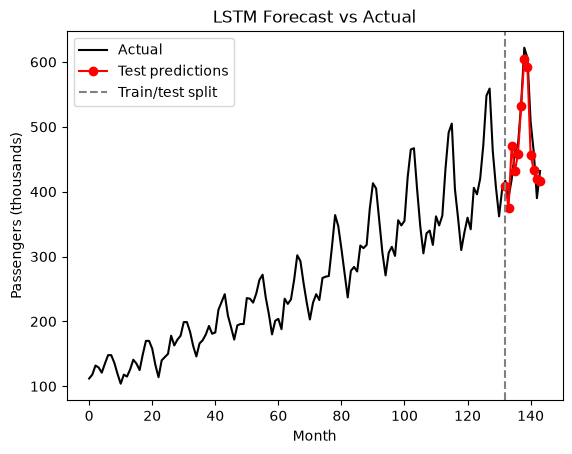

In [11]:
plt.plot(series, color="black", label="Actual")

test_months = np.arange(split_idx, len(series))
plt.plot(test_months, test_pred_real, color="red", marker="o", label="Test predictions")

plt.axvline(split_idx, color="gray", linestyle="--", label="Train/test split")
plt.xlabel("Month")
plt.ylabel("Passengers (thousands)")
plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.show()


Check: Your forecast plot should look approximately like this — the red test predictions closely tracking the actual black curve after the train/test split line:

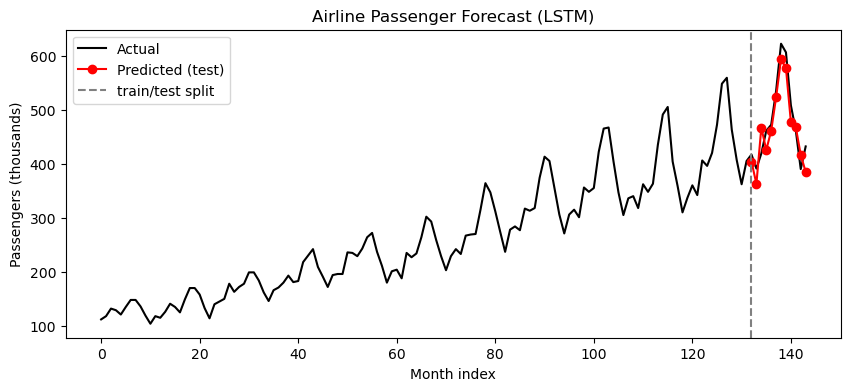